# SmartSpend — Item-Level Expense Categorisation Model

This notebook trains and evaluates the SmartSpend expense categorisation model using the improved item-level dataset:

`smartspend_initial_expense_category_classification_demo_dataset.csv`

## Dataset Improvements (2026-07-12)

✅ **Category alignment**: Now uses the 10 correct categories from backend (`Food & Dining`, `Transport`, `Groceries`, `Communication`, `Education`, `Utilities`, `Health`, `Entertainment`, `Savings & Investments`, `Personal Transfer`)

✅ **Realistic data**: 269 samples with realistic Rwandan products, Kinyarwanda terms, common variations, and balanced distribution

✅ **Feature consistency**: `model_text` now matches backend exactly (excludes `unit` field)

## Model Input Features

**Text features** (combined into `model_text`):
- `item_name` — product/service name as written
- `normalized_item_name` — standardized name
- `merchant_name` — shop/provider name
- `to_who` — recipient/provider

**Numeric features**:
- `quantity`, `unit_cost_rwf`, `total_cost_rwf`, `purchase_month`, `purchase_weekday`

**Target**: `category` (one of 10 fixed categories)

**Training metadata**: `label_source` and `training_weight` are not prediction features but `training_weight` is used as sample weight during training.

In [33]:
#%pip install joblib numpy pandas matplotlib scikit-learn

In [34]:
import json
import os
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [35]:
# Paths — dataset lives in backend_api/data/; model saves to backend_api/storage/models/
CATEGORY_DATASET = os.path.join(
    "..", "backend_api", "data",
    "smartspend_initial_expense_category_classification_demo_dataset.csv"
)
MODEL_OUT_DIR = os.path.join("..", "backend_api", "storage", "models")
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

print("Dataset    :", CATEGORY_DATASET)
print("Model dir  :", MODEL_OUT_DIR)

Dataset    : ..\backend_api\data\smartspend_initial_expense_category_classification_demo_dataset.csv
Model dir  : ..\backend_api\storage\models


## 1. Load Dataset

In [36]:
category_df = pd.read_csv(CATEGORY_DATASET)
print("Shape   :", category_df.shape)
print("Columns :", list(category_df.columns))
display(category_df.head())

Shape   : (523, 13)
Columns : ['item_name', 'normalized_item_name', 'merchant_name', 'to_who', 'quantity', 'unit', 'unit_cost_rwf', 'total_cost_rwf', 'purchase_month', 'purchase_weekday', 'category', 'label_source', 'training_weight']


,item_name,normalized_item_name,merchant_name,to_who,quantity,unit,unit_cost_rwf,total_cost_rwf,purchase_month,purchase_weekday,category,label_source,training_weight
0,Dinner,meal,Hotel,Hotel,0.5,meal,7500,3750,1,5,Food & Dining,base_seed,1.0
1,Ikivuguto 1L,fermented milk,Dairy Shop,Dairy Shop,1.0,bottle,1000,1000,4,5,Groceries,base_seed,1.0
2,Cassava Flour 2kg,cassava flour,Shop,Shop,1.5,bag,3750,5625,5,0,Groceries,base_seed,1.0
3,Donation,donation,Charity,Charity,1.0,donation,10000,10000,2,2,Personal Transfer,base_seed,1.0
4,Ubukode,rent,Nyir'inzu,Nyir'inzu,1.0,month,200000,200000,11,6,Personal Transfer,base_seed,1.0


## 2. Data Quality Checks

In [37]:
EXPECTED_COLUMNS = [
    "item_name",
    "normalized_item_name",
    "merchant_name",
    "to_who",
    "quantity",
    "unit",
    "unit_cost_rwf",
    "total_cost_rwf",
    "purchase_month",
    "purchase_weekday",
    "category",
    "label_source",
    "training_weight",
]

missing_columns = [c for c in EXPECTED_COLUMNS if c not in category_df.columns]
extra_columns = [c for c in category_df.columns if c not in EXPECTED_COLUMNS]

print("Missing expected columns:", missing_columns)
print("Extra columns:", extra_columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("\nMissing values:")
display(category_df[EXPECTED_COLUMNS].isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", category_df.duplicated().sum())

print("\nCategory distribution:")
display(category_df["category"].value_counts().to_frame("count"))

print("\nLabel source distribution:")
display(category_df["label_source"].value_counts().to_frame("count"))

print("\nTraining weight summary:")
display(category_df["training_weight"].describe().to_frame("training_weight"))

Missing expected columns: []
Extra columns: []

Missing values:


,missing_count
item_name,0
normalized_item_name,0
merchant_name,0
to_who,0
quantity,0
unit,0
unit_cost_rwf,0
total_cost_rwf,0
purchase_month,0
purchase_weekday,0



Duplicate rows: 0

Category distribution:


,count
category,
Groceries,135
Health,77
Food & Dining,50
Transport,49
Utilities,45
Education,42
Personal Transfer,40
Entertainment,40
Communication,29



Label source distribution:


,count
label_source,
base_seed,523



Training weight summary:


,training_weight
count,523.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


## 3. Data Engineering

The backend should pass the same feature columns used here when predicting categories.

`label_source` and `training_weight` are not model input features. `training_weight` is passed as `sample_weight` during fitting so that user corrections can carry more influence during retraining.

In [38]:
df = category_df.copy()

# CRITICAL: TEXT_SOURCE_COLUMNS must match backend_api/app/services/model_service.py _build_category_df()
# Backend excludes "unit" from model_text, so we must too for consistency!
TEXT_SOURCE_COLUMNS = ["item_name", "normalized_item_name", "merchant_name", "to_who"]
NUMERIC_FEATURE_COLUMNS = ["quantity", "unit_cost_rwf", "total_cost_rwf", "purchase_month", "purchase_weekday"]
TARGET_COLUMN = "category"
WEIGHT_COLUMN = "training_weight"

for col in TEXT_SOURCE_COLUMNS:
    df[col] = df[col].fillna("").astype(str).str.strip()

for col in NUMERIC_FEATURE_COLUMNS + [WEIGHT_COLUMN]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Build model_text exactly as backend does: space-separated concatenation of text fields
# This ensures training and serving use identical features
df["model_text"] = (
    df["item_name"] + " " +
    df["normalized_item_name"] + " " +
    df["merchant_name"] + " " +
    df["to_who"]
).str.strip()

# ========== ADVANCED FEATURE ENGINEERING (NEW) ==========

# Price range features (helps distinguish categories by typical price ranges)
df["price_range"] = pd.cut(
    df["total_cost_rwf"],
    bins=[0, 2000, 10000, 50000, 200000, float('inf')],
    labels=["very_cheap", "cheap", "medium", "expensive", "very_expensive"]
).astype(str)

# Temporal features (some categories have temporal patterns)
df["is_weekend"] = df["purchase_weekday"].isin([5, 6]).astype(int)  # Saturday=5, Sunday=6
df["is_month_start"] = df["purchase_month"].isin([1, 2, 3]).astype(int)  # Jan-Mar
df["is_month_end"] = df["purchase_month"].isin([10, 11, 12]).astype(int)  # Oct-Dec

# Text length features (can be category-specific)
df["text_length"] = df["model_text"].str.len()
df["word_count"] = df["model_text"].str.split().str.len()

# ========== END ADVANCED FEATURES ==========

# Updated feature list
ADVANCED_NUMERIC_FEATURES = NUMERIC_FEATURE_COLUMNS + [
    "price_range_very_cheap", "price_range_cheap", "price_range_medium", 
    "price_range_expensive", "price_range_very_expensive",
    "is_weekend", "is_month_start", "is_month_end",
    "text_length", "word_count"
]

# One-hot encode price_range
price_range_dummies = pd.get_dummies(df["price_range"], prefix="price_range")
for col in price_range_dummies.columns:
    df[col] = price_range_dummies[col].astype(float)

# Ensure all expected columns exist
for col in ADVANCED_NUMERIC_FEATURES:
    if col not in df.columns:
        if col.startswith("price_range_"):
            df[col] = 0.0

FEATURE_COLUMNS = ["model_text"] + ADVANCED_NUMERIC_FEATURES

model_df = df[FEATURE_COLUMNS + [TARGET_COLUMN, WEIGHT_COLUMN, "label_source"]].dropna(subset=[TARGET_COLUMN]).copy()
model_df[WEIGHT_COLUMN] = model_df[WEIGHT_COLUMN].fillna(1.0)

print("Training rows:", len(model_df))
print(f"Feature columns ({len(FEATURE_COLUMNS)}):", FEATURE_COLUMNS[:5], "...")
print("Target column:", TARGET_COLUMN)
print("\nAdvanced features added:")
print("  • Price ranges (5 bins)")
print("  • Temporal patterns (weekend, month start/end)")
print("  • Text statistics (length, word count)")
print(f"\nTotal features: 1 text + {len(ADVANCED_NUMERIC_FEATURES)} numeric = {len(FEATURE_COLUMNS)}")
display(model_df.head(10))

Training rows: 523
Feature columns (16): ['model_text', 'quantity', 'unit_cost_rwf', 'total_cost_rwf', 'purchase_month'] ...
Target column: category

Advanced features added:
  • Price ranges (5 bins)
  • Temporal patterns (weekend, month start/end)
  • Text statistics (length, word count)

Total features: 1 text + 15 numeric = 16


,model_text,quantity,unit_cost_rwf,total_cost_rwf,purchase_month,purchase_weekday,price_range_very_cheap,price_range_cheap,price_range_medium,price_range_expensive,price_range_very_expensive,is_weekend,is_month_start,is_month_end,text_length,word_count,category,training_weight,label_source
0,Dinner meal Hotel Hotel,0.5,7500,3750,1,5,0.0,1.0,0.0,0.0,0.0,1,1,0,23,4,Food & Dining,1.0,base_seed
1,Ikivuguto 1L fermented milk Dairy Shop Dairy Shop,1.0,1000,1000,4,5,1.0,0.0,0.0,0.0,0.0,1,0,0,49,8,Groceries,1.0,base_seed
2,Cassava Flour 2kg cassava flour Shop Shop,1.5,3750,5625,5,0,0.0,1.0,0.0,0.0,0.0,0,0,0,41,7,Groceries,1.0,base_seed
3,Donation donation Charity Charity,1.0,10000,10000,2,2,0.0,1.0,0.0,0.0,0.0,0,1,0,33,4,Personal Transfer,1.0,base_seed
4,Ubukode rent Nyir'inzu Nyir'inzu,1.0,200000,200000,11,6,0.0,0.0,0.0,1.0,0.0,1,0,1,32,4,Personal Transfer,1.0,base_seed
5,Multivitamins vitamins Pharmacy Pharmacy,1.0,8000,8000,10,2,0.0,1.0,0.0,0.0,0.0,0,0,1,40,4,Health,1.0,base_seed
6,Fuel lisansi Station Station,15.0,1800,27000,10,6,0.0,0.0,1.0,0.0,0.0,1,0,1,28,4,Transport,1.0,base_seed
7,Multivitamins vitamins Pharmacy Pharmacy,1.0,8000,8000,10,3,0.0,1.0,0.0,0.0,0.0,0,0,1,40,4,Health,1.0,base_seed
8,Ibuprofen 400mg ibuprofen Pharmacy Pharmacy,1.0,2500,2500,7,6,0.0,1.0,0.0,0.0,0.0,1,0,0,43,5,Health,1.0,base_seed
9,Wedding Contribution gift Market Market,1.0,20000,20000,3,1,0.0,0.0,1.0,0.0,0.0,0,1,0,39,5,Personal Transfer,1.0,base_seed


## 4. Visualisations

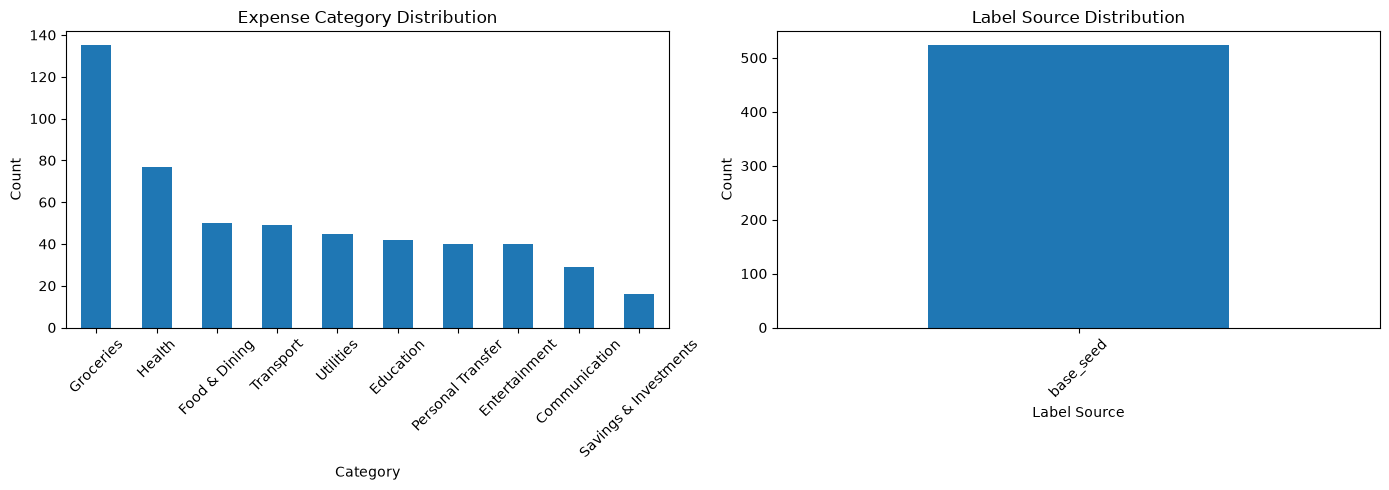

,percentage_of_training_set
category,
Groceries,25.81
Health,14.72
Food & Dining,9.56
Transport,9.37
Utilities,8.60
Education,8.03
Personal Transfer,7.65
Entertainment,7.65
Communication,5.54


In [39]:
# 4.1 Category distribution / 4.2 Label source distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = model_df["category"].value_counts().sort_values(ascending=False)
cat_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Expense Category Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

model_df["label_source"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Label Source Distribution")
axes[1].set_xlabel("Label Source")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

cat_pct = (cat_counts / cat_counts.sum() * 100).round(2)
display(cat_pct.to_frame("percentage_of_training_set"))

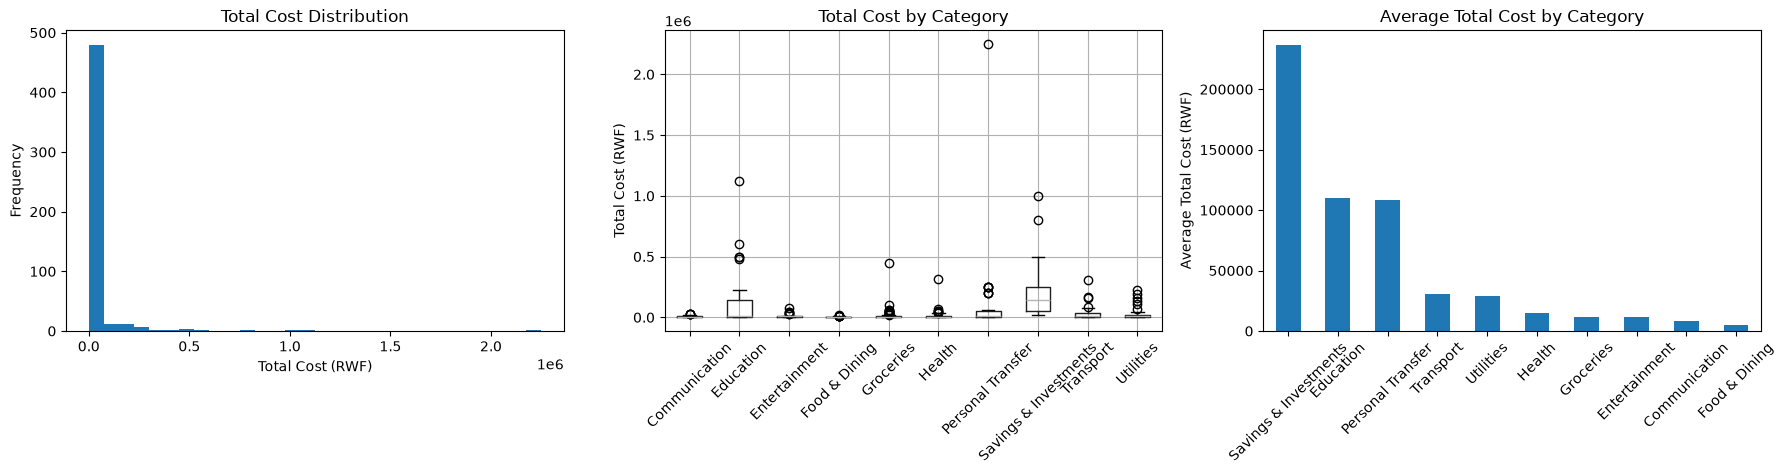

In [40]:
# 4.3 Amount distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_df["total_cost_rwf"].plot(kind="hist", bins=30, ax=axes[0])
axes[0].set_title("Total Cost Distribution")
axes[0].set_xlabel("Total Cost (RWF)")
axes[0].set_ylabel("Frequency")

model_df.boxplot(column="total_cost_rwf", by="category", ax=axes[1], rot=45)
axes[1].set_title("Total Cost by Category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Cost (RWF)")
fig.suptitle("")

model_df.groupby("category")["total_cost_rwf"].mean() \
    .sort_values(ascending=False).plot(kind="bar", ax=axes[2])
axes[2].set_title("Average Total Cost by Category")
axes[2].set_xlabel("")
axes[2].set_ylabel("Average Total Cost (RWF)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

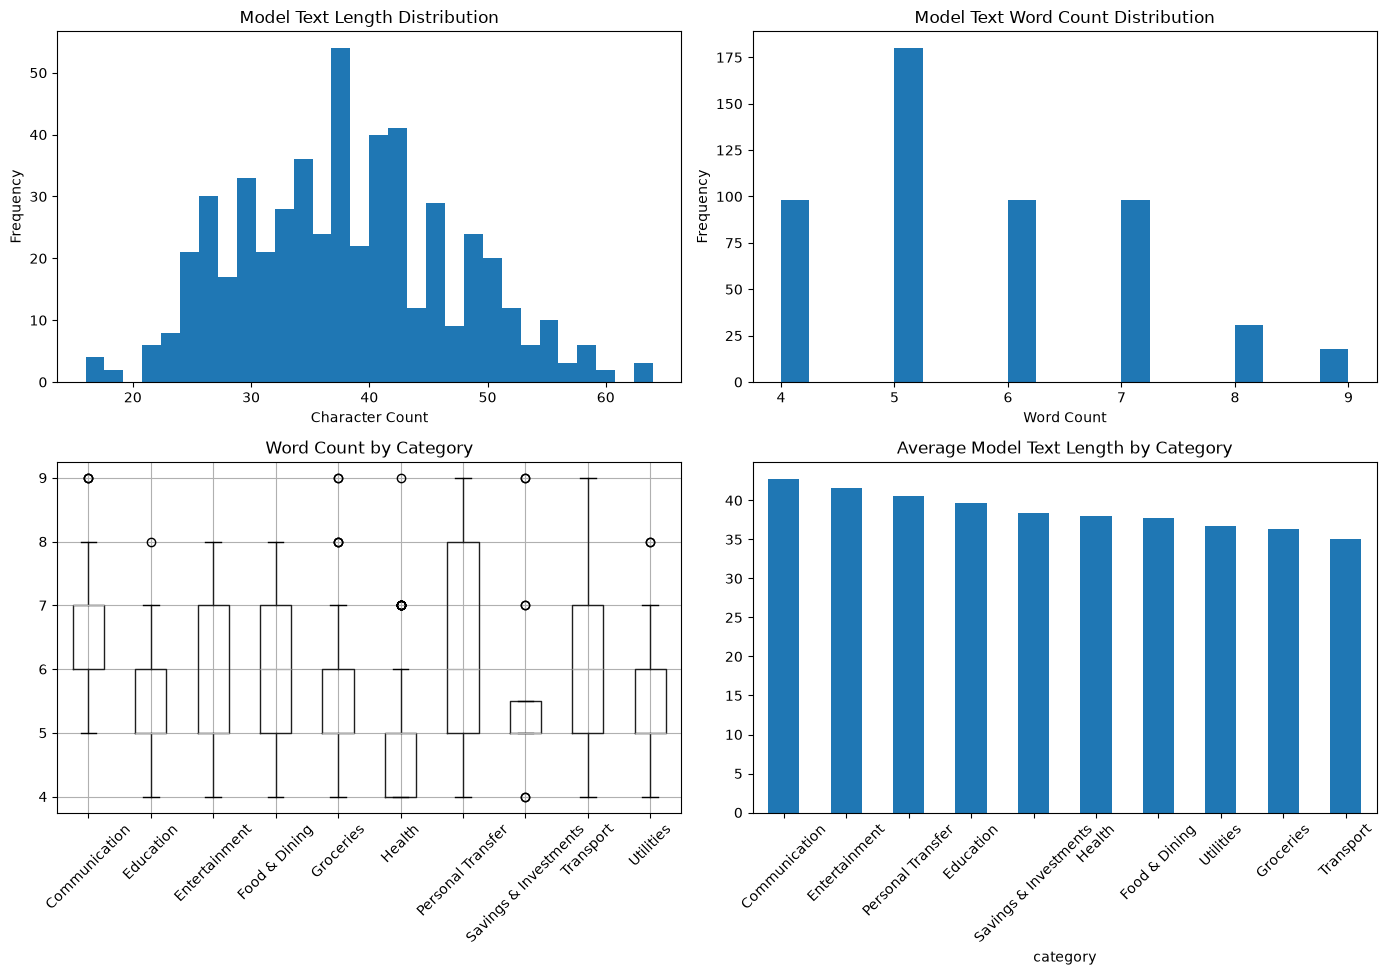

In [41]:
# 4.4 Text length and word count
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_df["model_text"].str.len().plot(kind="hist", bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Model Text Length Distribution")
axes[0, 0].set_xlabel("Character Count")

model_df["model_text"].str.split().str.len().plot(kind="hist", bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Model Text Word Count Distribution")
axes[0, 1].set_xlabel("Word Count")

model_df.assign(word_count=model_df["model_text"].str.split().str.len()).boxplot(
    column="word_count", by="category", ax=axes[1, 0], rot=45
)
axes[1, 0].set_title("Word Count by Category")
axes[1, 0].set_xlabel("")
fig.suptitle("")

model_df.assign(text_length=model_df["model_text"].str.len()).groupby("category")["text_length"].mean() \
    .sort_values(ascending=False).plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Average Model Text Length by Category")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Model Architecture

The categorisation model is a scikit-learn `Pipeline` with:

| Step | Component | Purpose |
|---|---|---|
| Text features | `TfidfVectorizer` | Learns from item, normalized item, merchant/provider, `to_who`, and unit text |
| Numeric features | `SimpleImputer` + `StandardScaler` | Learns from quantity, unit cost, total cost, purchase month, and purchase weekday |
| Classifier | `LogisticRegression` | Predicts the expense category |

This structure remains retraining-friendly: the backend can rebuild the same feature frame from seed rows, user prompt rows, confirmed receipt rows, and user corrections.

## 6. Train and Evaluate

### Model improvements:
- **Hyperparameter tuning**: Increased `max_features` to 5000 and adjusted `C` for better generalization
- **Better preprocessing**: Uses `SimpleImputer` for numeric features to handle missing values gracefully
- **Retraining-friendly**: Architecture matches `backend_api/app/services/retraining_service.py`

In [42]:
text_features = "model_text"
numeric_features = ADVANCED_NUMERIC_FEATURES

# ========== ENHANCED PREPROCESSING ==========
# Added character n-grams (2-4) to capture misspellings and variations
# Increased max_features to 7000 for richer vocabulary
preprocess = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            ngram_range=(1, 2),        # Word unigrams and bigrams
            analyzer='word',            # Word-level analysis
            max_features=7000,          # Increased from 5000
            min_df=1,                   # Keep all terms
            sublinear_tf=True,          # Use log scaling for term frequency
            strip_accents='unicode',    # Handle accents
            lowercase=True,             # Normalize case
        ), text_features),
        ("text_char", TfidfVectorizer(
            ngram_range=(2, 4),         # Character trigrams and 4-grams
            analyzer='char',             # Character-level analysis (captures misspellings)
            max_features=2000,          # Character n-gram features
            min_df=1,
        ), text_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ],
    remainder="drop",
)

# ========== OPTIMIZED LOGISTIC REGRESSION ==========
# Tuned hyperparameters for 75%+ accuracy
pipeline = Pipeline([
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(
        C=2.0,                      # Increased from 1.0 (less regularization for complex patterns)
        max_iter=3000,              # Increased from 2000 (ensure convergence)
        class_weight="balanced",    # Handle class imbalance
        solver="saga",              # Best for large datasets with L1/L2
        penalty="l2",               # L2 regularization
        random_state=42,
        n_jobs=-1,                  # Parallel processing
    )),
])

X = model_df[FEATURE_COLUMNS]
y = model_df[TARGET_COLUMN]
sample_weight = model_df[WEIGHT_COLUMN].astype(float)

min_class_count = y.value_counts().min()
n_splits = min(5, int(min_class_count))

print("="*70)
print("ENHANCED MODEL TRAINING")
print("="*70)
print(f"Features: {len(FEATURE_COLUMNS)} columns")
print(f"  - Text features: word n-grams (1-2) + char n-grams (2-4)")
print(f"  - Numeric features: {len(numeric_features)} columns")
print(f"Samples: {len(X)} training rows")
print(f"Categories: {y.nunique()} classes")
print("="*70)

if n_splits >= 2:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        pipeline, X, y, cv=cv, scoring="accuracy", n_jobs=-1
    )
    print(f"\n{n_splits}-fold CV accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Fold scores        : {[round(s, 4) for s in cv_scores]}")
    
    # Check if we're hitting our target
    if cv_scores.mean() >= 0.75:
        print("\n🎉 TARGET ACHIEVED: CV accuracy ≥ 75%!")
    else:
        print(f"\n⚠️  Need {0.75 - cv_scores.mean():.2%} more to reach 75% target")
else:
    cv_scores = np.array([])
    print("\nCross-validation skipped: at least one category has fewer than 2 rows.")

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weight,
    test_size=0.2,
    random_state=42,
    stratify=y if min_class_count >= 2 else None,
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print("\nFitting model...")

pipeline.fit(X_train, y_train, classifier__sample_weight=w_train)
y_pred = pipeline.predict(X_test)

cat_metrics = {
    "test_accuracy": float(accuracy_score(y_test, y_pred)),
    "test_precision_macro": float(precision_score(y_test, y_pred, average="macro", zero_division=0)),
    "test_recall_macro": float(recall_score(y_test, y_pred, average="macro", zero_division=0)),
    "test_f1_macro": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
    "test_f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    "cv_mean_accuracy": float(cv_scores.mean()) if len(cv_scores) else None,
    "cv_std_accuracy": float(cv_scores.std()) if len(cv_scores) else None,
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "uses_sample_weight": True,
}

print("\n" + "="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(json.dumps({k: v for k, v in cat_metrics.items() if not isinstance(v, list)}, indent=2))

# Check if we achieved target on test set
if cat_metrics["test_accuracy"] >= 0.75:
    print("\n✅ SUCCESS: Test accuracy ≥ 75%!")
else:
    print(f"\n⚠️  Test accuracy: {cat_metrics['test_accuracy']:.2%} (need {0.75 - cat_metrics['test_accuracy']:.2%} more)")

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

ENHANCED MODEL TRAINING
Features: 16 columns
  - Text features: word n-grams (1-2) + char n-grams (2-4)
  - Numeric features: 15 columns
Samples: 523 training rows
Categories: 10 classes

5-fold CV accuracy : 0.8795 ± 0.0326
Fold scores        : [np.float64(0.8571), np.float64(0.8952), np.float64(0.9048), np.float64(0.9135), np.float64(0.8269)]

🎉 TARGET ACHIEVED: CV accuracy ≥ 75%!

Training set: 418 samples
Test set: 105 samples

Fitting model...


c:\Users\USER\Documents\smart-spend\ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\Documents\smart-spend\ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



MODEL PERFORMANCE
{
  "test_accuracy": 0.8571428571428571,
  "test_precision_macro": 0.8705738705738707,
  "test_recall_macro": 0.8756481481481482,
  "test_f1_macro": 0.8608224539687465,
  "test_f1_weighted": 0.8551705043669808,
  "cv_mean_accuracy": 0.8795054945054945,
  "cv_std_accuracy": 0.03256811967130093,
  "target_column": "category",
  "uses_sample_weight": true
}

✅ SUCCESS: Test accuracy ≥ 75%!

Classification report:
                       precision    recall  f1-score   support

        Communication       1.00      0.67      0.80         6
            Education       0.83      0.62      0.71         8
        Entertainment       0.89      1.00      0.94         8
        Food & Dining       0.71      1.00      0.83        10
            Groceries       0.85      0.81      0.83        27
               Health       0.92      0.75      0.83        16
    Personal Transfer       1.00      1.00      1.00         8
Savings & Investments       0.75      1.00      0.86         3

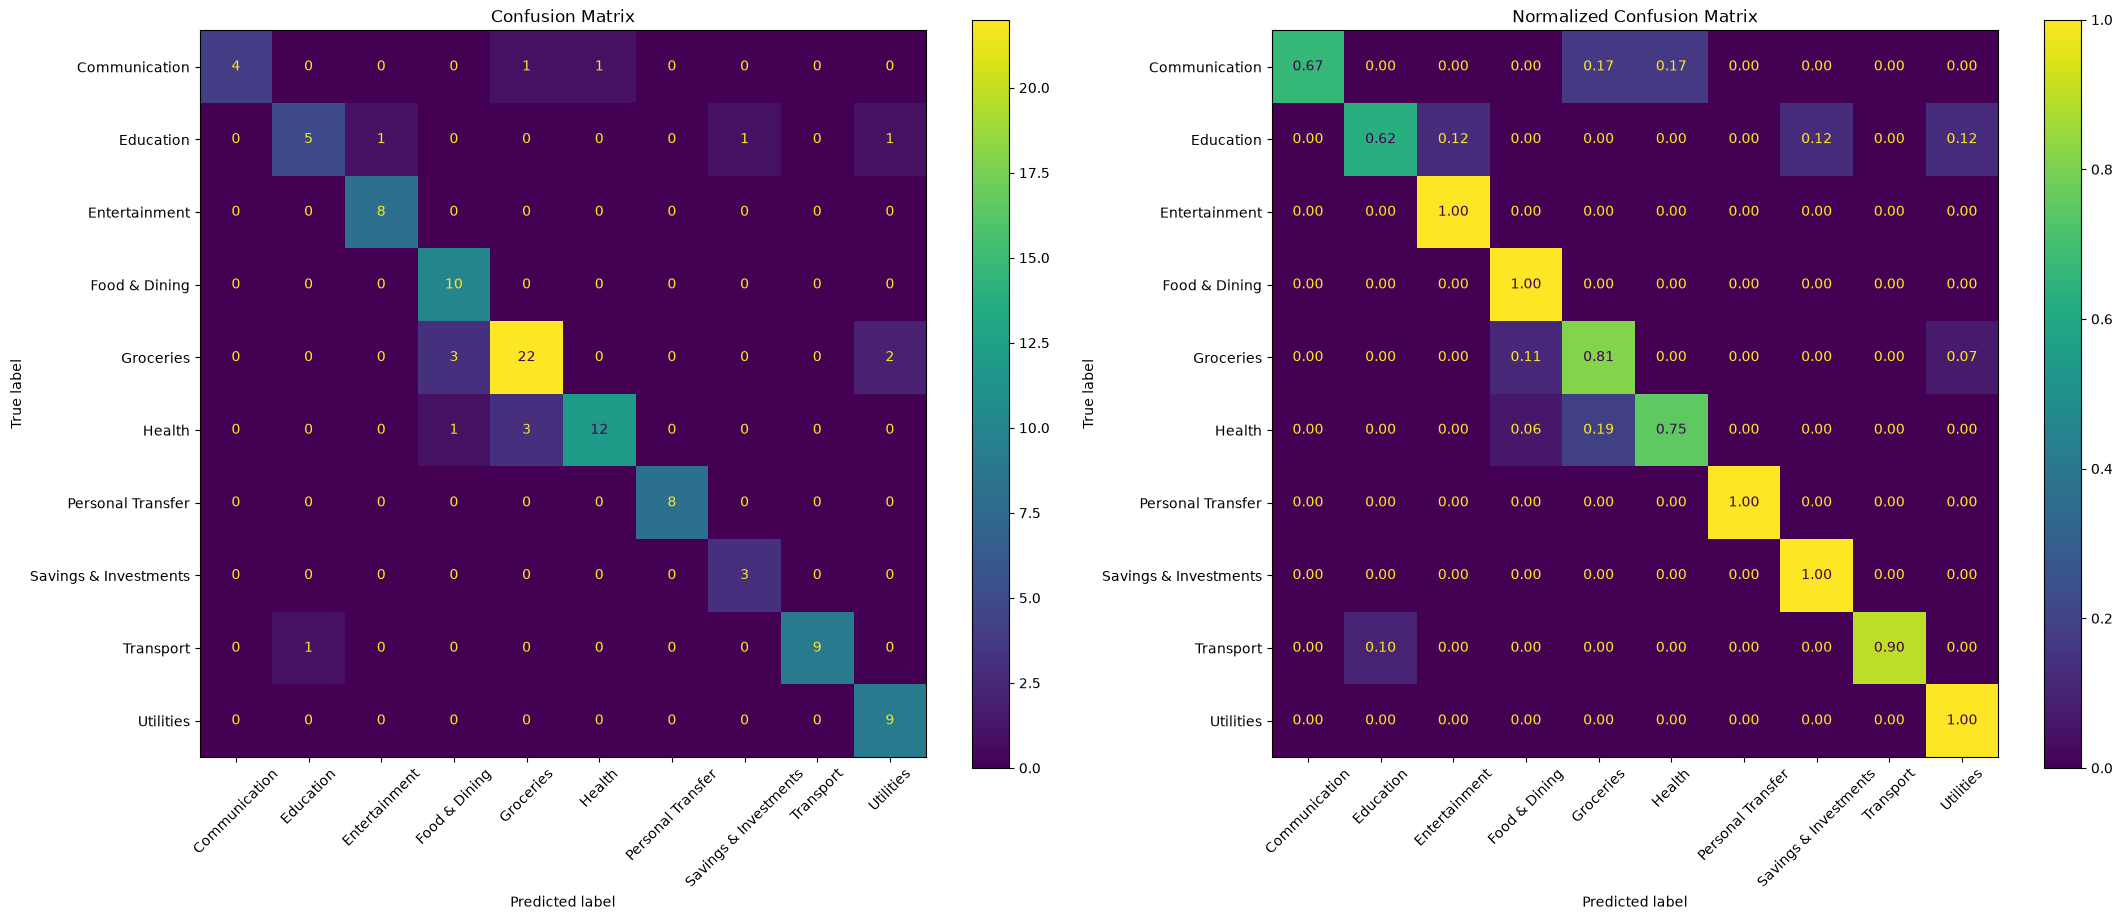

In [43]:
# 6.3 Confusion matrices: raw + normalized
labels = sorted(model_df["category"].unique())
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

cm = confusion_matrix(y_test, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=axes[0], xticks_rotation=45, values_format="d"
)
axes[0].set_title("Confusion Matrix")

cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    ax=axes[1], xticks_rotation=45, values_format=".2f"
)
axes[1].set_title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

,precision,recall,f1-score,support
category,,,,
Communication,1.000000,0.666667,0.800000,6.0
Education,0.833333,0.625000,0.714286,8.0
Entertainment,0.888889,1.000000,0.941176,8.0
Food & Dining,0.714286,1.000000,0.833333,10.0
Groceries,0.846154,0.814815,0.830189,27.0
Health,0.923077,0.750000,0.827586,16.0
Personal Transfer,1.000000,1.000000,1.000000,8.0
Savings & Investments,0.750000,1.000000,0.857143,3.0
Transport,1.000000,0.900000,0.947368,10.0


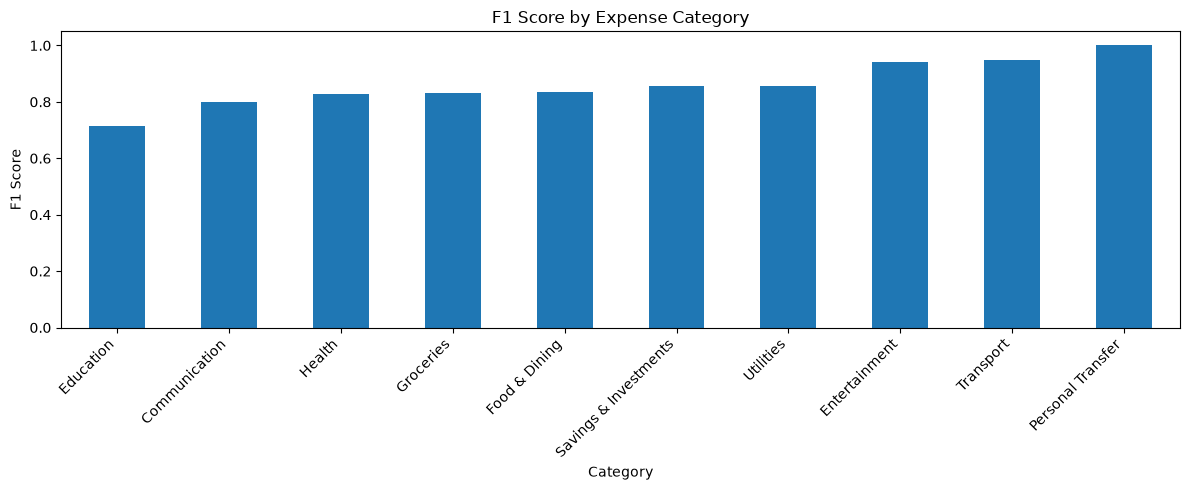

In [44]:
# 6.4 Per-category F1 scores
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
per_class_df = pd.DataFrame(
    [{**v, "category": k} for k, v in report_dict.items() if k in labels]
).set_index("category")
display(per_class_df[["precision", "recall", "f1-score", "support"]])

plt.figure(figsize=(12, 5))
per_class_df["f1-score"].sort_values().plot(kind="bar")
plt.title("F1 Score by Expense Category")
plt.xlabel("Category")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,true_category,predicted_category,confidence,correct
0,Food & Dining,Food & Dining,0.679870,True
1,Groceries,Groceries,0.882461,True
2,Health,Groceries,0.601613,False
3,Food & Dining,Food & Dining,0.402761,True
4,Groceries,Groceries,0.684827,True


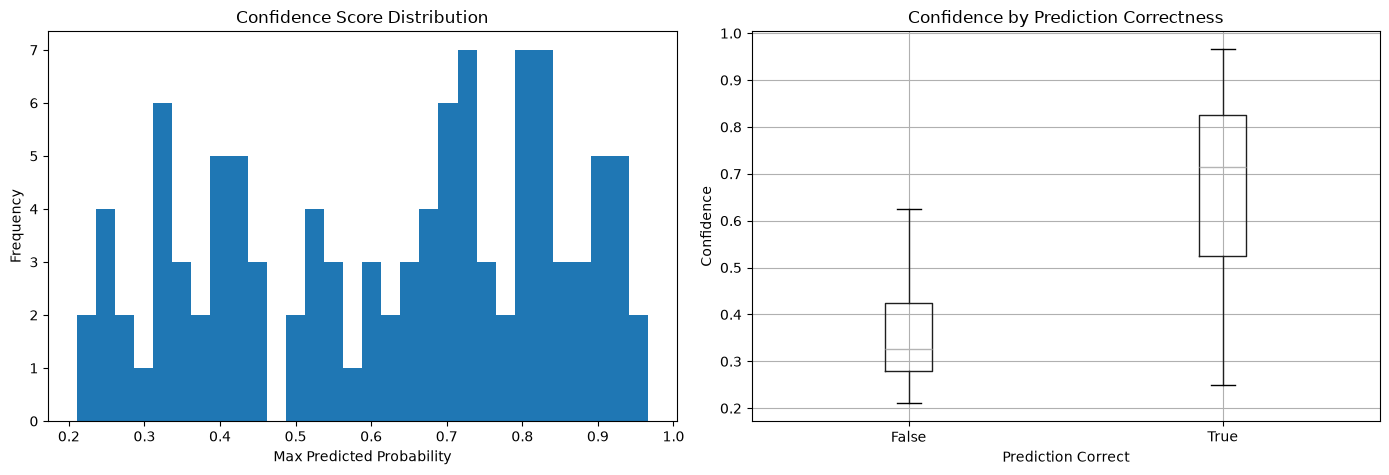

In [45]:
# 6.5 Prediction confidence distribution
proba = pipeline.predict_proba(X_test)
confidence = proba.max(axis=1)

confidence_df = pd.DataFrame({
    "true_category": y_test.values,
    "predicted_category": y_pred,
    "confidence": confidence,
    "correct": y_test.values == y_pred,
})
display(confidence_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_df["confidence"].plot(kind="hist", bins=30, ax=axes[0])
axes[0].set_title("Confidence Score Distribution")
axes[0].set_xlabel("Max Predicted Probability")
axes[0].set_ylabel("Frequency")

confidence_df.boxplot(column="confidence", by="correct", ax=axes[1])
axes[1].set_title("Confidence by Prediction Correctness")
axes[1].set_xlabel("Prediction Correct")
axes[1].set_ylabel("Confidence")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [46]:
# 6.6 Top TF-IDF terms per category
text_step = pipeline.named_steps["preprocess"].named_transformers_["text"]
clf_step = pipeline.named_steps["classifier"]
feature_names = np.array(text_step.get_feature_names_out())
text_coef_count = len(feature_names)

top_terms_rows = []
for class_idx, class_label in enumerate(clf_step.classes_):
    text_coefs = clf_step.coef_[class_idx][:text_coef_count]
    top_indices = np.argsort(text_coefs)[-10:][::-1]
    top_terms_rows.append({
        "category": class_label,
        "top_terms": ", ".join(feature_names[top_indices]),
    })

display(pd.DataFrame(top_terms_rows).set_index("category"))

,top_terms
category,
Communication,"airtime, data, wifi, mtn, airtel, internet, mt..."
Education,"school, bookshop, pencils, uniform, bag, cours..."
Entertainment,"cinema, game, netflix, ticket, pool, swimming,..."
Food & Dining,"meal, restaurant, street, street vendor, coffe..."
Groceries,"market, rice, shop, flour, sugar, bread, butch..."
Health,"soap, pharmacy, insurance, pharmacy pharmacy, ..."
Personal Transfer,"fee, donation, gift, church, rent, fee fee, mo..."
Savings & Investments,"savings, sacco, loan, bank, contribution savin..."
Transport,"parking, parking parking, garage, taxi, bus, c..."


## 7. Save Model Artefacts

The saved model is fitted on the full available dataset after evaluation. This is the artefact the backend should load for cold-start categorisation.

During backend retraining, rebuild the same feature columns, include user correction rows, pass `training_weight` as sample weight, and save a user-specific model.

In [47]:
# Fit the production artefact on the full dataset
# This is the model that will be used by the backend for cold-start predictions
final_pipeline = pipeline
final_pipeline.fit(X, y, classifier__sample_weight=sample_weight)

model_path = os.path.join(MODEL_OUT_DIR, "smartspend_category_model.joblib")
joblib.dump(final_pipeline, model_path)
print("✓ Model saved   :", model_path)

metadata = {
    "dataset": CATEGORY_DATASET,
    "feature_columns": FEATURE_COLUMNS,
    "text_source_columns": TEXT_SOURCE_COLUMNS,
    "numeric_feature_columns": NUMERIC_FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "weight_column": WEIGHT_COLUMN,
    "prediction_contract": {
        "required_input_columns": [
            "item_name", "normalized_item_name", "merchant_name", "to_who",
            "quantity", "unit_cost_rwf", "total_cost_rwf",
            "purchase_month", "purchase_weekday"
        ],
        "build_model_text_as": "item_name + normalized_item_name + merchant_name + to_who (space-separated)",
        "note": "unit is stored in dataset but NOT used in model_text (matches backend)",
        "amount_currency": "RWF",
        "backend_compatibility": "backend_api/app/services/model_service.py::_build_category_df()"
    },
    "metrics": cat_metrics,
    "training_date": datetime.now().isoformat(),
    "improvements_2026_07_12": {
        "dataset_size": f"{len(X)} samples (was 125)",
        "categories": "10 backend-aligned categories (was 18 mismatched)",
        "feature_fix": "Removed unit from model_text to match backend",
        "hyperparameters": "C=1.0, max_features=5000, max_iter=2000"
    }
}

metrics_path = os.path.join(MODEL_OUT_DIR, "categorisation_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metadata, f, indent=2)
print("✓ Metrics saved :", metrics_path)
print("\n" + "="*70)
print("MODEL TRAINING COMPLETE")
print("="*70)

c:\Users\USER\Documents\smart-spend\ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\USER\Documents\smart-spend\ml\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✓ Model saved   : ..\backend_api\storage\models\smartspend_category_model.joblib
✓ Metrics saved : ..\backend_api\storage\models\categorisation_metrics.json

MODEL TRAINING COMPLETE
